# Question 1: What does $\braket{\sigma \sigma }_{z,x}$ look like at equilibrium?

In [333]:
import sys

sys.path.append("../../src")

from equilibrium_critical_correlations import sigma_general as sigma_x

from equilibrium_z_projectors import sigma_general as sigma_z

import kibble_zurek as kz

from common_imports import *

from numpy.fft import fft, fftfreq, fftshift


Text(0.5, 0, 'r')

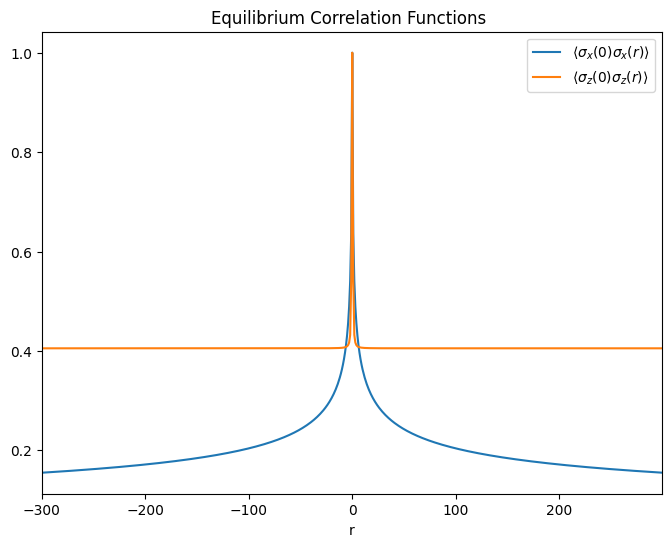

In [341]:
r = np.arange(-300,300)

xx_lab = r"$\langle \sigma_x (0) \sigma_x (r) \rangle $"
zz_lab = r"$\langle \sigma_z(0) \sigma_z (r) \rangle $"

C_xx = array([sigma_x([0,ri]) for ri in r])
C_zz = array([sigma_z([0,ri]) for ri in r])


plt.figure(figsize=(8,6))

plot(r,C_xx,label= xx_lab)
plot(r,C_zz,label= zz_lab)
legend()
xlim(min(r),max(r))
title("Equilibrium Correlation Functions ")
xlabel("r")

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_16632/2922134618.py:14: RuntimeWarning: divide by zero encountered in power
  plot(r,r**(-2.)/6.28,"--k",label=r"$r^{-2}$")
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_16632/2922134618.py:15: RuntimeWarning: divide by zero encountered in power
  plot(r,r**(-1/4)/2,ls="-.", color="black", label=r"$r^{-1/4}$")
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_16632/2922134618.py:15: RuntimeWarning: invalid value encountered in power
  plot(r,r**(-1/4)/2,ls="-.", color="black", label=r"$r^{-1/4}$")


Text(0.5, 0, 'r')

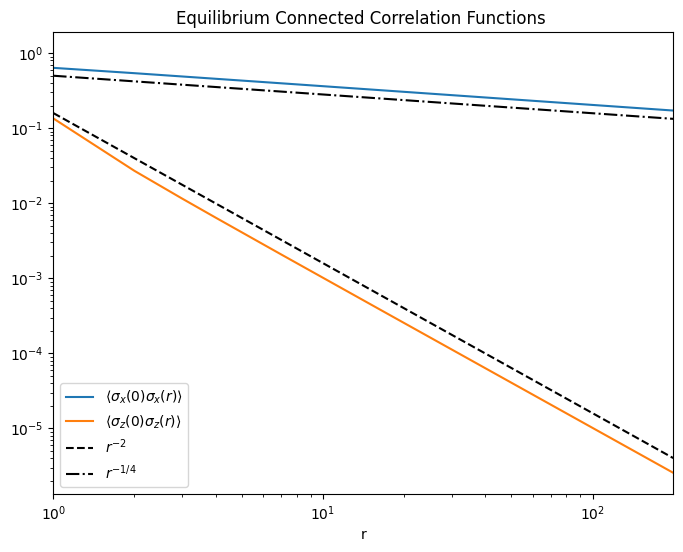

In [342]:
r = np.arange(-200,200)

xx_lab = r"$\langle \sigma_x (0) \sigma_x (r) \rangle $"
zz_lab = r"$\langle \sigma_z(0) \sigma_z (r) \rangle $"

C_xx = array([sigma_x([0,ri]) for ri in r])
C_zz = array([sigma_z([0,ri])- sigma_z([0])**2 for ri in r])


plt.figure(figsize=(8,6))

plot(r,C_xx,label= xx_lab)
plot(r,C_zz,label= zz_lab)
plot(r,r**(-2.)/6.28,"--k",label=r"$r^{-2}$")
plot(r,r**(-1/4)/2,ls="-.", color="black", label=r"$r^{-1/4}$")
legend()
xlim(1,max(r))
loglog()
title("Equilibrium Connected Correlation Functions ")
xlabel("r")

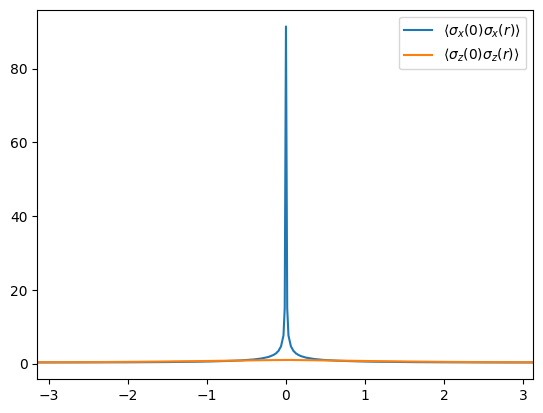

# Normalize by integral

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_16632/2612681668.py:7: RuntimeWarning: divide by zero encountered in power
  plot(k,abs(k)**(-3/4)/1.5,"--k",label=r"$|k|^{-3/4}$")


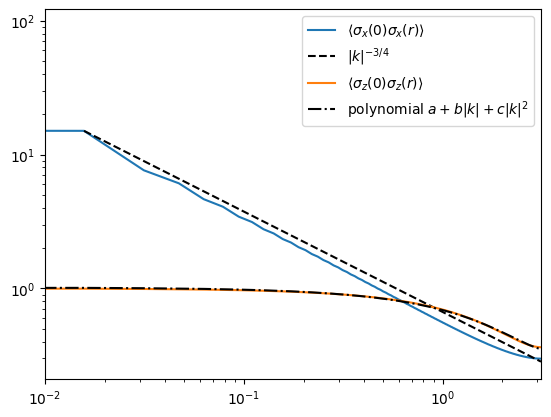

In [344]:
dk= k[1]-k[0]
N_xx= 1#np.real(sum((F_xx))*dk)
N_zz = 1# np.real(sum((F_zz))*dk)


plot(k,abs(F_xx),label = xx_lab)
plot(k,abs(k)**(-3/4)/1.5,"--k",label=r"$|k|^{-3/4}$")
plot(k,abs(F_zz),label=  zz_lab)
plot(k,poly_abs(abs(k)),ls="-.",color="black",label=r"polynomial $a+b|k|+c|k|^2$")#*abs(k)**(-1/32))
#plot(k,k)
xlim(0.01,max(k))
loglog()#ylim(.1,1)
legend()
#ylim(0,1)

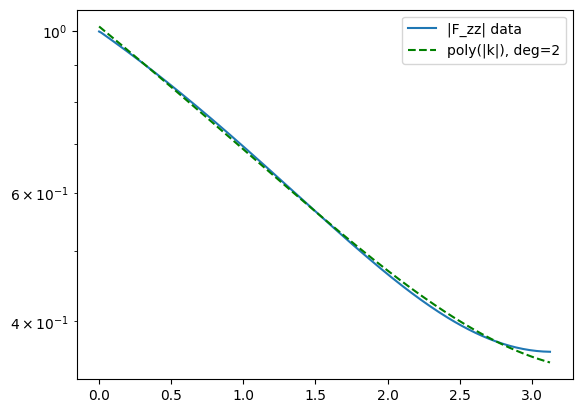

In [345]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# use |k| for all fits
k_abs = k[k>=0]

# polynomial fit in |k|
deg = 2
coeffs_abs = np.polyfit(k_abs, np.abs(F_zz[k>=0]), deg)
poly_abs = np.poly1d(coeffs_abs)

# plot comparison
plt.plot(k_abs, np.abs(F_zz[k>=0]), label='|F_zz| data')
plt.plot(k_abs, poly_abs(k_abs), '--g', label=f'poly(|k|), deg={deg}')
plt.yscale('log')
plt.legend()
plt.show()


# QUENCHING 

In [346]:
taus = array([.1, 1, 10, 100])

import kibble_zurek as kibble_x
import time_evolved_z_correlators as kibble_z

In [347]:
L = 500
states = [kibble_x.state(L,tau,0) for tau in taus]

In [ ]:
quenched_xx = [array([kibble_x.sigma_general([0,ri],s) for ri in tqdm(r)]) for s in states]


/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
100%|██████████| 400/400 [00:55<00:00,  7.26it/s]
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/time_evolved_z_correlators.py:49: ComplexWarning: Ca

In [348]:
quenched_zz = [array([kibble_z.sigma_general([0,ri],s)-kibble_z.sigma_general([0],s)**2 for ri in tqdm(r)]) for s in states]

  0%|          | 0/400 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/time_evolved_z_correlators.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)
100%|██████████| 400/400 [00:00<00:00, 14134.85it/s]


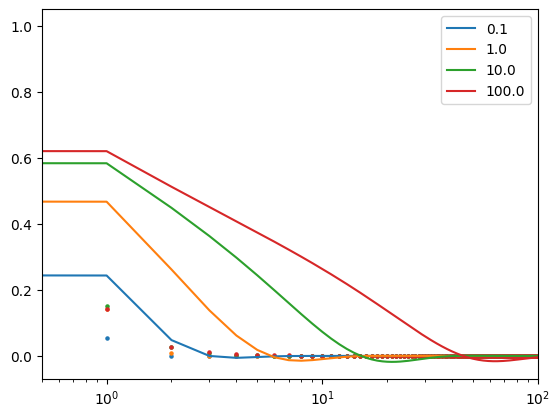

In [349]:
for i, tau in enumerate(taus):
    xx = quenched_xx[i]
    zz = quenched_zz[i]

    plot(r,xx,label=f"{tau}")
    scatter(r,zz,s=5)

xlim(0.5,100)
xscale("log")
legend()

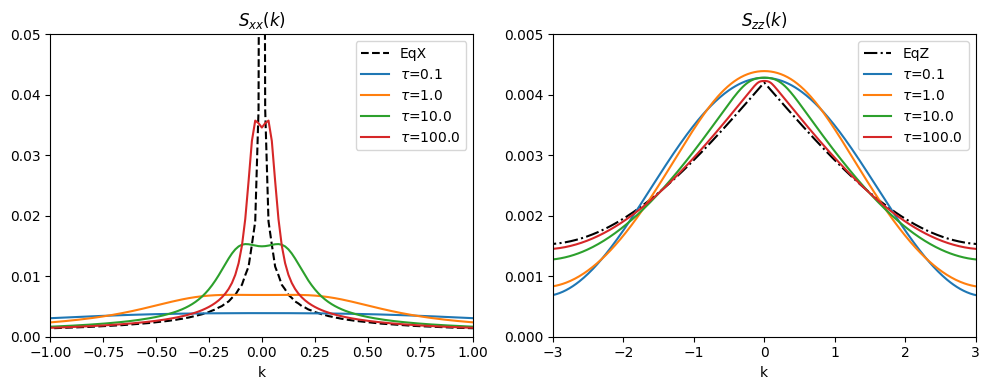

In [350]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# --- σ^xσ^x structure factor ---
axs[0].plot(k, np.abs(FT(C_xx)) / np.sum(np.abs(FT(C_xx))), '--k', label="EqX")
for i, tau in enumerate(taus):
    F_xx = FT(quenched_xx[i])
    axs[0].plot(k, np.abs(F_xx) / np.sum(np.abs(F_xx)), label=rf"$\tau$={tau}")
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(0, 0.05)
axs[0].legend()
axs[0].set_title(r"$S_{xx}(k)$")
axs[0].set_xlabel("k")

# --- σ^zσ^z structure factor ---
axs[1].plot(k, np.abs(FT(C_zz)) / np.sum(np.abs(FT(C_zz))), '-.k', label="EqZ")
for i, tau in enumerate(taus):
    F_zz = FT(quenched_zz[i])
    axs[1].plot(k, np.abs(F_zz) / np.sum(np.abs(F_zz)),label=rf"$\tau$={tau}")
axs[1].set_xlim(-3, 3)
axs[1].set_ylim(0, 0.005)

axs[1].legend()
axs[1].set_title(r"$S_{zz}(k)$")
axs[1].set_xlabel("k")

plt.tight_layout()
plt.show()


In [278]:
rhos = array([ sigma_x([0,1])-kibble_x.sigma_general([0,1],s) for s in states])

print(rhos)

#print([(tau)**(1/2)/2 for tau in taus])


[0.39295629 0.1693115  0.05286914 0.01621807]


In [241]:
r = np.arange(-100,100)
n = 1
PP_1 = [[array([kibble_x.P_n_correlations(n,ri,s)-kibble_x.P_n(n,s)**2 for ri in (r)]) for s in  tqdm(states)]]


























100%|██████████| 4/4 [00:26<00:00,  6.66s/it]


In [242]:
r = np.arange(-100,100)
n = 2
PP_2 = [[array([kibble_x.P_n_correlations(n,ri,s)-kibble_x.P_n(n,s)**2 for ri in (r)]) for s in  tqdm(states)]]






/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)




















100%|██████████| 4/4 [01:21<00:00, 20.27s/it]


In [243]:
r = np.arange(-100,100)
n = 3
PP_3 = [[array([kibble_x.P_n_correlations(n,ri,s)-kibble_x.P_n(n,s)**2 for ri in (r)]) for s in  tqdm(states)]]


























100%|██████████| 4/4 [05:19<00:00, 79.88s/it]


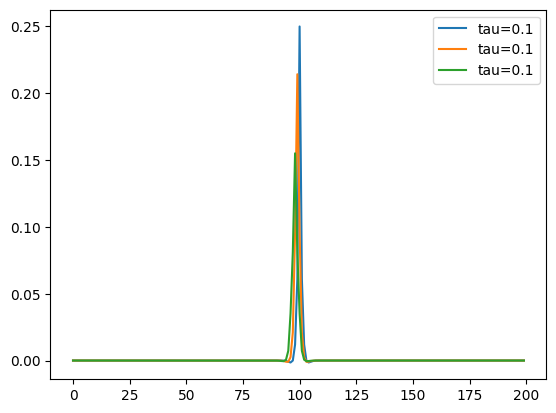

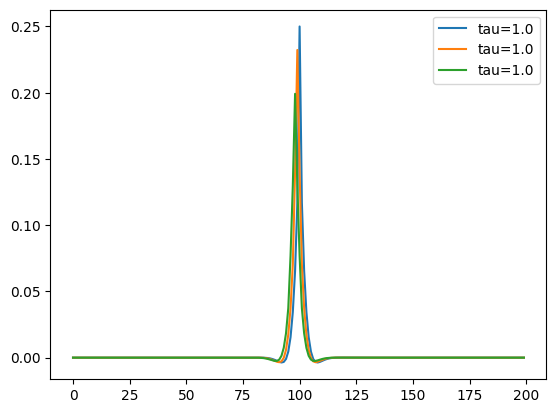

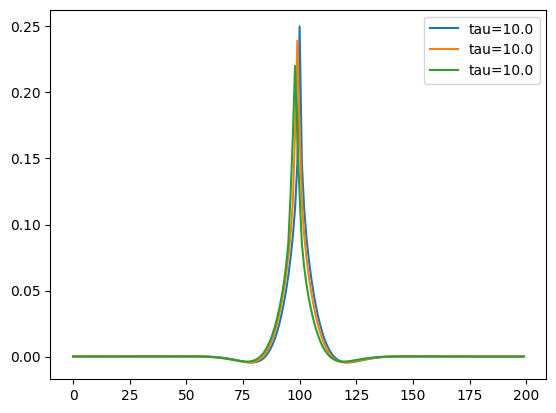

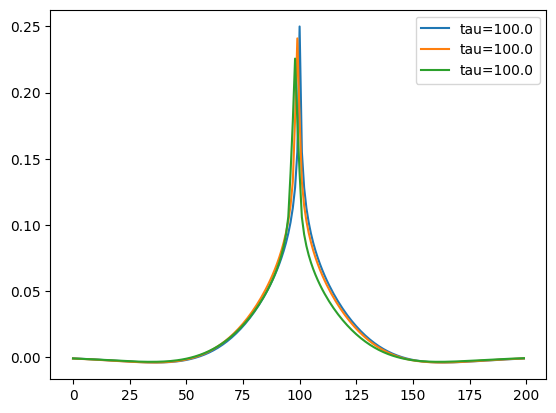

In [265]:
for i, tau in enumerate(taus):
    plot(PP_1[0][i],label=f"tau={tau}")
    plot(PP_2[0][i],label=f"tau={tau}")
    plot(PP_3[0][i],label=f"tau={tau}")
    legend()

    show()


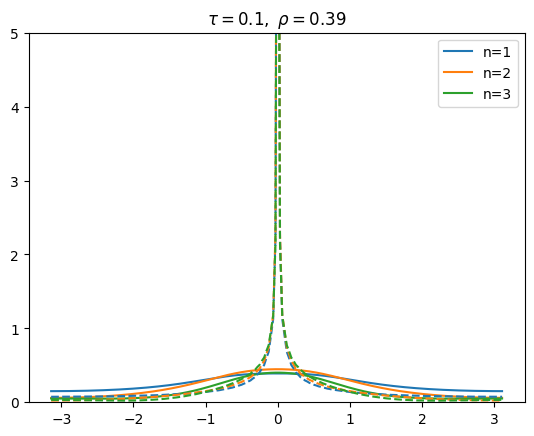

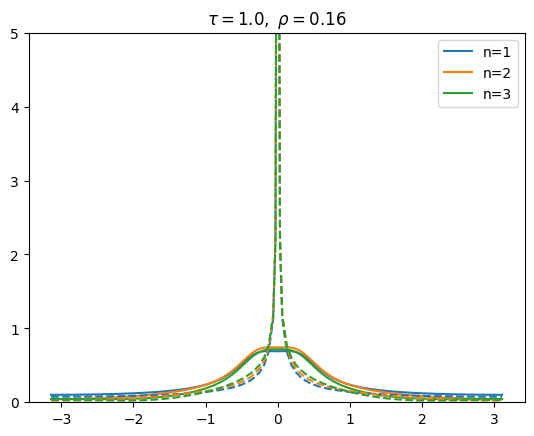

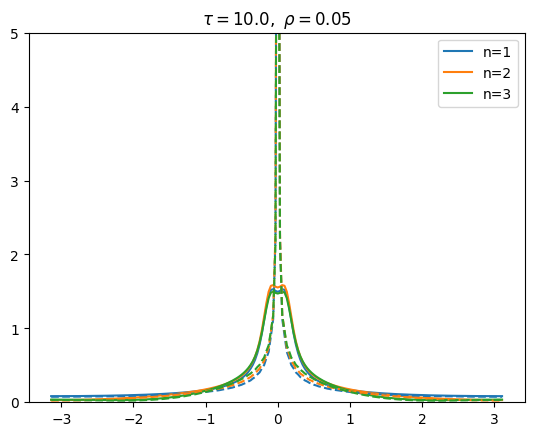

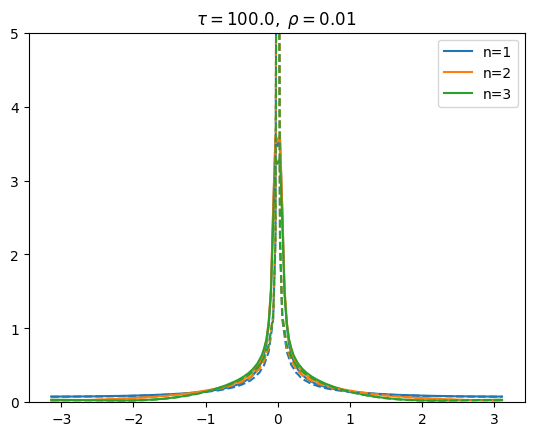

In [289]:
k = K(r)
F_1gs= FT(P1_gs)
F_2gs= FT(P2_gs)
F_3gs= FT(P3_gs)

colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, tau in enumerate(taus):
    F_1 = FT(PP_1[0][i])
    F_2 = FT(PP_2[0][i])
    F_3 = FT(PP_3[0][i])

    plt.plot(k, abs(F_1), color=colors[0], label="n=1")
    plt.plot(k, abs(F_2), color=colors[1], label="n=2")
    plt.plot(k, abs(F_3), color=colors[2], label="n=3")

    plt.plot(k, abs(F_1gs), "--", color=colors[0])
    plt.plot(k, abs(F_2gs), "--", color=colors[1])
    plt.plot(k, abs(F_3gs), "--", color=colors[2])

    plt.title(rf"$\tau = {tau},\ \rho = {str(rhos[i])[:4]}$")
    plt.legend()
    plt.ylim(0, 5)
    plt.show()


In [283]:
from equilibrium_critical_correlations import P_n, P_n_correlations

P1_gs = array([P_n_correlations(1,ri)-P_n(1)**2 for ri in tqdm(r)])
P2_gs = array([P_n_correlations(2,ri)-P_n(2)**2 for ri in tqdm(r)])
P3_gs = array([P_n_correlations(3,ri)-P_n(3)**2 for ri in tqdm(r)])

  0%|          | 0/200 [00:00<?, ?it/s]/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
100%|██████████| 200/200 [00:01<00:00, 176.50it/s]


# To the ordered phase 



In [352]:
states = [kibble_x.state(L,tau,tau) for tau in taus]
rhos = array([ (1-kibble_x.sigma_general([0,1],s))/2 for s in states])

print(rhos)

#print([(tau)**(1/2)/2 for tau in taus])


[0.36213031 0.13381756 0.03585301 0.01125966]


/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


In [353]:
r = np.arange(-100,100)
n = 1
PP_1 = [[array([kibble_x.P_n_correlations(n,ri,s)-kibble_x.P_n(n,s)**2 for ri in (r)]) for s in  tqdm(states)]]

  0%|          | 0/4 [00:00<?, ?it/s]/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
100%|██████████| 4/4 [00:25<00:00,  6.45s/it]


In [354]:
r = np.arange(-100,100)
n = 2
PP_2 = [[array([kibble_x.P_n_correlations(n,ri,s)-kibble_x.P_n(n,s)**2 for ri in (r)]) for s in  tqdm(states)]]

100%|██████████| 4/4 [01:19<00:00, 19.98s/it]


In [355]:
r = np.arange(-100,100)
n = 3
PP_3 = [[array([kibble_x.P_n_correlations(n,ri,s)-kibble_x.P_n(n,s)**2 for ri in (r)]) for s in  tqdm(states)]]

100%|██████████| 4/4 [05:21<00:00, 80.42s/it]


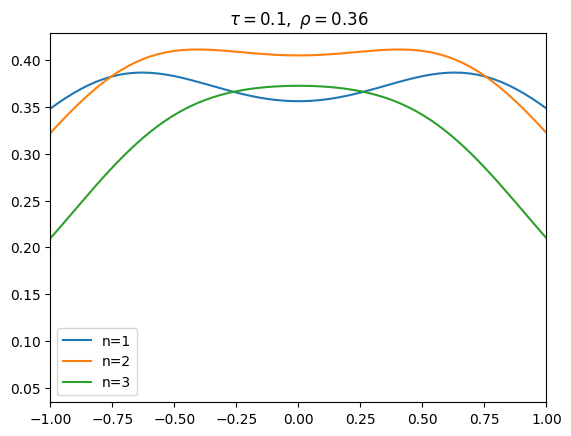

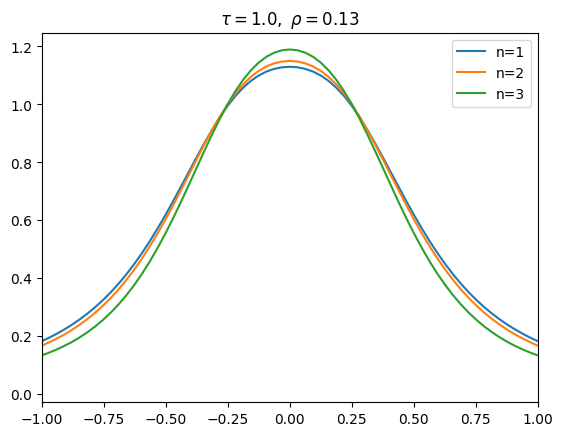

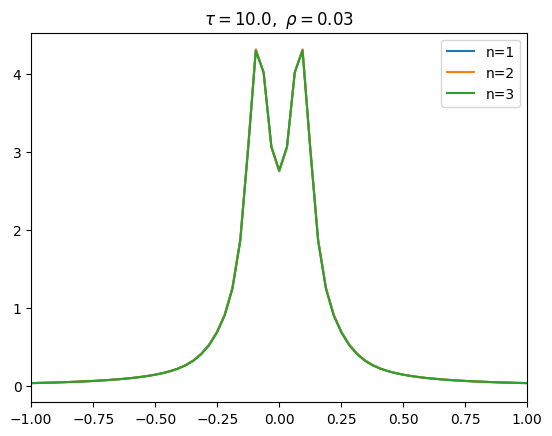

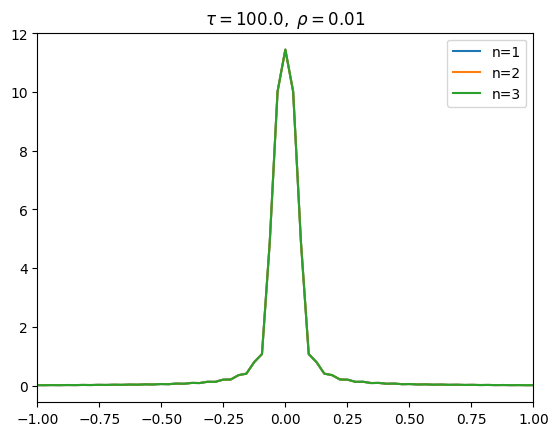

In [359]:
k = K(r)
F_1gs= FT(P1_gs)
F_2gs= FT(P2_gs)
F_3gs= FT(P3_gs)

colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, tau in enumerate(taus):
    F_1 = FT(PP_1[0][i])
    F_2 = FT(PP_2[0][i])
    F_3 = FT(PP_3[0][i])

    plt.plot(k, abs(F_1), color=colors[0], label="n=1")
    plt.plot(k, abs(F_2), color=colors[1], label="n=2")
    plt.plot(k, abs(F_3), color=colors[2], label="n=3")

   # plt.plot(k, abs(F_1gs), "--", color=colors[0])
   # plt.plot(k, abs(F_2gs), "--", color=colors[1])
   #plt.plot(k, abs(F_3gs), "--", color=colors[2])
    xlim(-1,1)
    plt.title(rf"$\tau = {tau},\ \rho = {str(rhos[i])[:4]}$")
    plt.legend()
   # plt.ylim(0, 5)
    plt.show()


# More Thorough Equilibrium ground state study

In [299]:
GroundStates = [array([P_n_correlations(n,ri)-P_n(n)**2 for ri in tqdm(r)]) for n in np.arange(1,7)]


100%|██████████| 200/200 [01:16<00:00,  2.62it/s]


Text(0, 0.5, '$S_n(k)$')

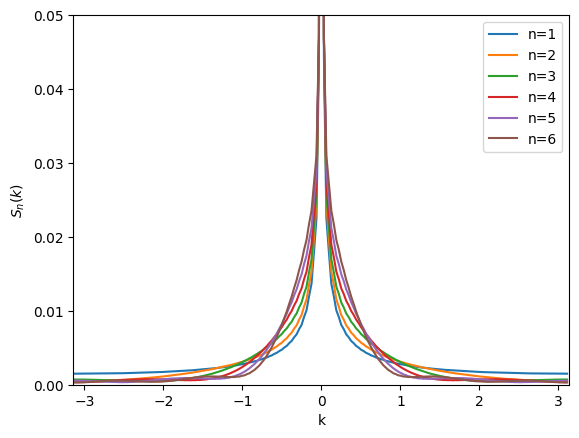

In [362]:
x = np.arange(1,7)
areas = []
for g,xi in zip(GroundStates[::1],x[::1]):
    f = FT(g)
    area= sum(abs(f))*(k[1]-k[0])
    f /= sum(abs(f))
    plot(k,abs(f),label=f"n={xi}")
    areas.append(area)
    
legend()
xlim(-3.14,3.14)
ylim(0.,0.05)
#xscale("log")
xlabel("k")
ylabel(r"$S_n(k)$")
#loglog()

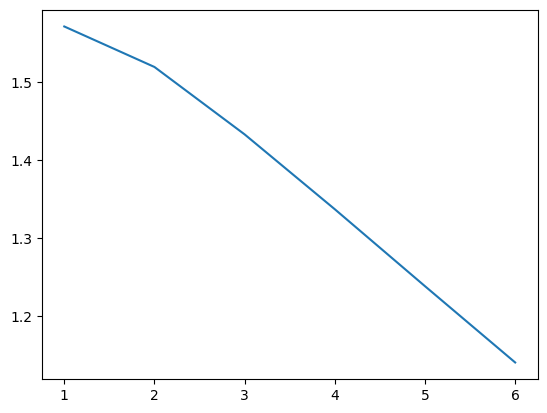